# Model 1A, CatBoost Experiment 05: Final Representation and Capacity Search

This append-only experiment makes one final bounded attempt to improve CatBoost 1A-04. It retains the exact flight rows, target, 24-hour rotation mask, compact airport-wide W60 backlog, and compact same-airline W60 backlog.

The experiment first screens four predeclared representations with the CatBoost 1A-04 classifier fixed. The selected representation is then tested with a bounded capacity search and one chronological-order comparison. Every choice, including the operating threshold, uses five expanding folds within 2019. The frozen design is evaluated once on 2023. No new feature dataset is written, and 2024 is not loaded.


In [1]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4

CONTROL_ITERATIONS = 683
CONTROL_DEPTH = 6
CONTROL_LEARNING_RATE = 0.03
CONTROL_L2_LEAF_REG = 3
MAX_SEARCH_ITERATIONS = 2000
EARLY_STOPPING_ROUNDS = 100

MIN_AP_GAIN = 0.003
MIN_FOLD_WINS = 4
MAX_BRIER_INCREASE = 0.001

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost {catboost.__version__}")


CatBoost 1.2.10


## Pair and validate the established feature paths

The full-history rotation, airport-wide W60 backlog, and same-airline W60 backlog datasets are paired in memory after exact identity and causal-construction checks.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Apply the 24-hour mask and define the representation screen

The control is CatBoost 1A-04's exact 41-field allowlist. The schedule-cycle variant adds four existing cyclical clock fields. The compact-weather variant adds six existing weather transformations. The combined variant adds both blocks. These are allowlist changes only; all fields already exist in the established departure feature dataset.


In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(
        result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce"
    ).gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}

BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]

CONTROL_NUMERIC_FEATURES = [
    *BASE_NUMERIC_FEATURES,
    *ROTATION_NUMERIC,
    *COMPACT_BACKLOG_FEATURES,
    *SELECTED_AIRLINE_BACKLOG_FEATURES,
]
SCHEDULE_CYCLE_FEATURES = [
    "SCHED_DEP_TIME_SIN", "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN", "SCHED_ARR_TIME_COS",
]
COMPACT_WEATHER_FEATURES = [
    "TEMP_DEWPOINT_SPREAD", "LOG_PRECIPITATION",
    "WindX", "WindY", "ADVERSE_WEATHER", "NOAA_AGE_MINUTES",
]
all_numeric_features = list(dict.fromkeys([
    *CONTROL_NUMERIC_FEATURES,
    *SCHEDULE_CYCLE_FEATURES,
    *COMPACT_WEATHER_FEATURES,
]))

feature_variants = {
    "control_41": [*categorical_features, *CONTROL_NUMERIC_FEATURES],
    "schedule_cycle_45": [
        *categorical_features, *CONTROL_NUMERIC_FEATURES, *SCHEDULE_CYCLE_FEATURES,
    ],
    "compact_weather_47": [
        *categorical_features, *CONTROL_NUMERIC_FEATURES, *COMPACT_WEATHER_FEATURES,
    ],
    "combined_51": [
        *categorical_features, *CONTROL_NUMERIC_FEATURES,
        *SCHEDULE_CYCLE_FEATURES, *COMPACT_WEATHER_FEATURES,
    ],
}
expected_counts = {
    "control_41": 41,
    "schedule_cycle_45": 45,
    "compact_weather_47": 47,
    "combined_51": 51,
}
for name, fields in feature_variants.items():
    assert len(fields) == len(set(fields)) == expected_counts[name], name

required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET,
    *categorical_features, *all_numeric_features,
]))
for partition, frame in model_frames.items():
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing fields: {missing}"

forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(set().union(*map(set, feature_variants.values())))

pd.DataFrame([
    {
        "variant": name,
        "source_fields": len(fields),
        "categorical_fields": len(categorical_features),
        "numeric_fields": len(fields) - len(categorical_features),
        "schedule_cycle_additions": len(set(fields).intersection(SCHEDULE_CYCLE_FEATURES)),
        "compact_weather_additions": len(set(fields).intersection(COMPACT_WEATHER_FEATURES)),
    }
    for name, fields in feature_variants.items()
]).set_index("variant")


,source_fields,categorical_fields,numeric_fields,schedule_cycle_additions,compact_weather_additions
variant,,,,,
control_41,41,6,35,0,0
schedule_cycle_45,45,6,39,4,0
compact_weather_47,47,6,41,0,6
combined_51,51,6,45,4,6


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in all_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_variants = {
    name: train_model_df[fields].reset_index(drop=True)
    for name, fields in feature_variants.items()
}
X_validation_variants = {
    name: validation_model_df[fields].reset_index(drop=True)
    for name, fields in feature_variants.items()
}

assert training_dates.max() < validation_dates.min()
pd.DataFrame({
    "training": [len(y_train), y_train.mean(), training_dates.min(), training_dates.max()],
    "external_validation": [
        len(y_validation), y_validation.mean(), validation_dates.min(), validation_dates.max()
    ],
}, index=["rows", "delay_rate", "start", "end"])


,training,external_validation
rows,107430,109983
delay_rate,0.1877,0.2364
start,2019-01-01 00:00:00,2023-01-01 00:00:00
end,2019-12-31 00:00:00,2023-12-31 00:00:00


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Screen the four representations using 2019

The fixed CatBoost 1A-04 classifier isolates the representation change. A new representation must improve mean fold AP by at least 0.003, win at least four of five folds, and avoid worsening mean Brier score by more than 0.001. Otherwise, the 41-field control remains selected.


In [7]:
def make_catboost_model(
    *,
    iterations,
    depth,
    learning_rate,
    random_strength=1,
    has_time=False,
    use_best_model=False,
):
    return CatBoostClassifier(
        iterations=iterations,
        loss_function="Logloss",
        eval_metric="PRAUC:type=Classic",
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=CONTROL_L2_LEAF_REG,
        random_strength=random_strength,
        has_time=has_time,
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS,
        allow_writing_files=False,
        verbose=False,
        use_best_model=use_best_model,
    )


screen_start = perf_counter()
screen_rows = []
screen_oof = {name: np.full(len(y_train), np.nan) for name in feature_variants}
for variant, X_variant in X_train_variants.items():
    for fold, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            iterations=CONTROL_ITERATIONS,
            depth=CONTROL_DEPTH,
            learning_rate=CONTROL_LEARNING_RATE,
        )
        model.fit(
            X_variant.iloc[train_idx], y_train.iloc[train_idx],
            cat_features=categorical_features, verbose=False,
        )
        probabilities = model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        screen_oof[variant][heldout_idx] = probabilities
        screen_rows.append({
            "variant": variant,
            "fold": fold,
            "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed representation {variant}")

screen_seconds = perf_counter() - screen_start
screen_fold_results = pd.DataFrame(screen_rows)
screen_results = (
    screen_fold_results.groupby("variant", as_index=False)
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

control_screen = screen_results.set_index("variant").loc["control_41"]
best_screen_name = str(screen_results.iloc[0]["variant"])
best_screen = screen_results.set_index("variant").loc[best_screen_name]
screen_pivot = screen_fold_results.pivot(
    index="fold", columns="variant", values="average_precision"
)
screen_wins = int((screen_pivot[best_screen_name] > screen_pivot["control_41"]).sum())
screen_ap_gain = float(
    best_screen["mean_average_precision"] - control_screen["mean_average_precision"]
)
screen_brier_change = float(
    best_screen["mean_brier_score"] - control_screen["mean_brier_score"]
)
screen_passes = (
    best_screen_name != "control_41"
    and screen_ap_gain >= MIN_AP_GAIN
    and screen_wins >= MIN_FOLD_WINS
    and screen_brier_change <= MAX_BRIER_INCREASE
)
selected_variant = best_screen_name if screen_passes else "control_41"

print(f"Representation screen completed in {screen_seconds:,.1f} seconds")
print(f"Highest-AP representation: {best_screen_name}")
print(f"AP gain versus control: {screen_ap_gain:.4f}; fold wins: {screen_wins}/5")
print(f"Brier change versus control: {screen_brier_change:+.4f}")
print(f"Guardrail passed: {screen_passes}")
print(f"Selected representation: {selected_variant}")
display(screen_results)
screen_pivot


Completed representation control_41


Completed representation schedule_cycle_45


Completed representation compact_weather_47


Completed representation combined_51
Representation screen completed in 292.0 seconds
Highest-AP representation: combined_51
AP gain versus control: 0.0014; fold wins: 5/5
Brier change versus control: -0.0003
Guardrail passed: False
Selected representation: control_41


,variant,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
0,combined_51,0.7032,0.0607,0.8458,0.0913
1,schedule_cycle_45,0.7026,0.0608,0.8449,0.0913
2,compact_weather_47,0.7022,0.0615,0.8451,0.0914
3,control_41,0.7018,0.0615,0.8448,0.0916


variant,combined_51,compact_weather_47,control_41,schedule_cycle_45
fold,,,,
1,0.6676,0.6642,0.6620,0.6643
2,0.7382,0.7379,0.7381,0.7394
3,0.7910,0.7914,0.7905,0.7902
4,0.6405,0.6399,0.6404,0.6428
5,0.6787,0.6776,0.6778,0.6763


## Retune the selected representation using 2019

The bounded search tests depths 6–8, learning rates 0.015 and 0.03, and split random strength 0 and 1. L2 leaf regularization remains 3 and class weighting remains off. Each fold can train up to 2,000 trees with early stopping. The original CatBoost 1A-04 configuration is retained unless the best candidate meets the same improvement and fold-stability guardrail.


In [8]:
parameter_candidates = [
    {
        "depth": depth,
        "learning_rate": learning_rate,
        "random_strength": random_strength,
    }
    for depth, learning_rate, random_strength
    in product([6, 7, 8], [0.015, 0.03], [0, 1])
]

X_selected_train = X_train_variants[selected_variant]
search_start = perf_counter()
search_rows = []
candidate_oof = {}
for candidate, parameters in enumerate(parameter_candidates, start=1):
    probabilities_all = np.full(len(y_train), np.nan)
    for fold, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            iterations=MAX_SEARCH_ITERATIONS,
            depth=parameters["depth"],
            learning_rate=parameters["learning_rate"],
            random_strength=parameters["random_strength"],
            use_best_model=True,
        )
        model.fit(
            X_selected_train.iloc[train_idx], y_train.iloc[train_idx],
            cat_features=categorical_features,
            eval_set=(X_selected_train.iloc[heldout_idx], y_train.iloc[heldout_idx]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose=False,
        )
        probabilities = model.predict_proba(X_selected_train.iloc[heldout_idx])[:, 1]
        probabilities_all[heldout_idx] = probabilities
        search_rows.append({
            "candidate": candidate,
            "fold": fold,
            **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    candidate_oof[candidate] = probabilities_all
    print(f"Completed candidate {candidate}/{len(parameter_candidates)}: {parameters}")

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (
    fold_search_results
    .groupby(["candidate", "depth", "learning_rate", "random_strength"], as_index=False)
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
        median_best_iteration=("best_iteration", "median"),
        max_best_iteration=("best_iteration", "max"),
    )
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
    .reset_index(drop=True)
)

baseline_filter = (
    candidate_results["depth"].eq(CONTROL_DEPTH)
    & candidate_results["learning_rate"].eq(CONTROL_LEARNING_RATE)
    & candidate_results["random_strength"].eq(1)
)
baseline_candidate = int(candidate_results.loc[baseline_filter, "candidate"].iloc[0])
best_candidate = int(candidate_results.iloc[0]["candidate"])
best_parameters_row = candidate_results.iloc[0]
baseline_row = candidate_results.loc[baseline_filter].iloc[0]

parameter_pivot = fold_search_results.pivot(
    index="fold", columns="candidate", values="average_precision"
)
parameter_wins = int(
    (parameter_pivot[best_candidate] > parameter_pivot[baseline_candidate]).sum()
)
parameter_ap_gain = float(
    best_parameters_row["mean_average_precision"] - baseline_row["mean_average_precision"]
)
parameter_brier_change = float(
    best_parameters_row["mean_brier_score"] - baseline_row["mean_brier_score"]
)
parameter_passes = (
    best_candidate != baseline_candidate
    and parameter_ap_gain >= MIN_AP_GAIN
    and parameter_wins >= MIN_FOLD_WINS
    and parameter_brier_change <= MAX_BRIER_INCREASE
)

if parameter_passes:
    selected_candidate = best_candidate
    selected_parameters = {
        "depth": int(best_parameters_row["depth"]),
        "learning_rate": float(best_parameters_row["learning_rate"]),
        "random_strength": float(best_parameters_row["random_strength"]),
    }
    selected_iterations = int(round(best_parameters_row["median_best_iteration"]))
else:
    selected_candidate = baseline_candidate
    selected_parameters = {
        "depth": CONTROL_DEPTH,
        "learning_rate": CONTROL_LEARNING_RATE,
        "random_strength": 1.0,
    }
    selected_iterations = CONTROL_ITERATIONS

print(f"Parameter search completed in {search_seconds:,.1f} seconds")
print(f"Highest-AP candidate: {best_candidate}")
print(f"AP gain versus search control: {parameter_ap_gain:.4f}; fold wins: {parameter_wins}/5")
print(f"Brier change versus search control: {parameter_brier_change:+.4f}")
print(f"Guardrail passed: {parameter_passes}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iterations: {selected_iterations}")
candidate_results


Completed candidate 1/12: {'depth': 6, 'learning_rate': 0.015, 'random_strength': 0}


Completed candidate 2/12: {'depth': 6, 'learning_rate': 0.015, 'random_strength': 1}


Completed candidate 3/12: {'depth': 6, 'learning_rate': 0.03, 'random_strength': 0}


Completed candidate 4/12: {'depth': 6, 'learning_rate': 0.03, 'random_strength': 1}


Completed candidate 5/12: {'depth': 7, 'learning_rate': 0.015, 'random_strength': 0}


...

Completed candidate 9/12: {'depth': 8, 'learning_rate': 0.015, 'random_strength': 0}


Completed candidate 10/12: {'depth': 8, 'learning_rate': 0.015, 'random_strength': 1}


Completed candidate 11/12: {'depth': 8, 'learning_rate': 0.03, 'random_strength': 0}


Completed candidate 12/12: {'depth': 8, 'learning_rate': 0.03, 'random_strength': 1}
Parameter search completed in 1,559.8 seconds
Highest-AP candidate: 11
AP gain versus search control: 0.0021; fold wins: 4/5
Brier change versus search control: -0.0006
Guardrail passed: False
Selected parameters: {'depth': 6, 'learning_rate': 0.03, 'random_strength': 1.0}
Selected iterations: 683


,candidate,depth,learning_rate,random_strength,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,max_best_iteration
0,11,8,0.0300,0,0.7058,0.0597,0.8467,0.0907,342.0000,629
1,9,8,0.0150,0,0.7057,0.0599,0.8466,0.0908,967.0000,1449
2,7,7,0.0300,0,0.7053,0.0596,0.8463,0.0908,457.0000,872
3,10,8,0.0150,1,0.7046,0.0600,0.8464,0.0912,"1,006.0000",1736
4,5,7,0.0150,0,0.7046,0.0601,0.8457,0.0910,978.0000,1367
5,8,7,0.0300,1,0.7045,0.0600,0.8465,0.0911,607.0000,1024
6,6,7,0.0150,1,0.7045,0.0600,0.8463,0.0912,"1,063.0000",1808
7,12,8,0.0300,1,0.7044,0.0603,0.8463,0.0910,518.0000,635
8,1,6,0.0150,0,0.7042,0.0598,0.8453,0.0911,"1,193.0000",1604
9,2,6,0.0150,1,0.7039,0.0606,0.8461,0.0913,"1,278.0000",1815


## Compare default and chronological CatBoost handling

The selected representation, classifier parameters, and tree count are held fixed. `has_time=True` is retained only if it clears the same 2019 guardrail; otherwise CatBoost's default permutation behavior remains selected.


In [9]:
chronology_start = perf_counter()
chronology_rows = []
chronology_oof = {
    False: np.full(len(y_train), np.nan),
    True: np.full(len(y_train), np.nan),
}
for has_time in [False, True]:
    for fold, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(
            iterations=selected_iterations,
            depth=selected_parameters["depth"],
            learning_rate=selected_parameters["learning_rate"],
            random_strength=selected_parameters["random_strength"],
            has_time=has_time,
        )
        model.fit(
            X_selected_train.iloc[train_idx], y_train.iloc[train_idx],
            cat_features=categorical_features, verbose=False,
        )
        probabilities = model.predict_proba(X_selected_train.iloc[heldout_idx])[:, 1]
        chronology_oof[has_time][heldout_idx] = probabilities
        chronology_rows.append({
            "has_time": has_time,
            "fold": fold,
            "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
    print(f"Completed has_time={has_time}")

chronology_seconds = perf_counter() - chronology_start
chronology_fold_results = pd.DataFrame(chronology_rows)
chronology_results = (
    chronology_fold_results.groupby("has_time", as_index=False)
    .agg(
        mean_average_precision=("average_precision", "mean"),
        std_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values("has_time")
)
chronology_indexed = chronology_results.set_index("has_time")
chronology_pivot = chronology_fold_results.pivot(
    index="fold", columns="has_time", values="average_precision"
)
chronology_wins = int((chronology_pivot[True] > chronology_pivot[False]).sum())
chronology_ap_gain = float(
    chronology_indexed.loc[True, "mean_average_precision"]
    - chronology_indexed.loc[False, "mean_average_precision"]
)
chronology_brier_change = float(
    chronology_indexed.loc[True, "mean_brier_score"]
    - chronology_indexed.loc[False, "mean_brier_score"]
)
chronology_passes = (
    chronology_ap_gain >= MIN_AP_GAIN
    and chronology_wins >= MIN_FOLD_WINS
    and chronology_brier_change <= MAX_BRIER_INCREASE
)
selected_has_time = bool(chronology_passes)
selected_oof_probabilities = chronology_oof[selected_has_time]

print(f"Chronology comparison completed in {chronology_seconds:,.1f} seconds")
print(f"AP gain from has_time=True: {chronology_ap_gain:.4f}; fold wins: {chronology_wins}/5")
print(f"Brier change from has_time=True: {chronology_brier_change:+.4f}")
print(f"Guardrail passed: {chronology_passes}")
print(f"Selected has_time: {selected_has_time}")
display(chronology_results)
chronology_pivot


Completed has_time=False


Completed has_time=True
Chronology comparison completed in 133.6 seconds
AP gain from has_time=True: 0.0010; fold wins: 4/5
Brier change from has_time=True: -0.0002
Guardrail passed: False
Selected has_time: False


,has_time,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
0,False,0.7018,0.0615,0.8448,0.0916
1,True,0.7028,0.0613,0.8444,0.0913


has_time,False,True
fold,,
1,0.6620,0.6675
2,0.7381,0.7388
3,0.7905,0.7908
4,0.6404,0.6382
5,0.6778,0.6785


## Select the operating threshold using 2019 only

The threshold that maximizes exact F1 is selected from aggregated held-out 2019 probabilities produced by the fully selected representation and model.


In [10]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_mask = np.isfinite(selected_oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = selected_oof_probabilities[oof_mask]
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(oof_y, oof_p)
threshold_results = pd.DataFrame({
    "threshold": curve_thresholds,
    "precision": curve_precision[:-1],
    "recall": curve_recall[:-1],
})
threshold_results["f1"] = np.divide(
    2 * threshold_results["precision"] * threshold_results["recall"],
    threshold_results["precision"] + threshold_results["recall"],
    out=np.zeros(len(threshold_results)),
    where=(threshold_results["precision"] + threshold_results["recall"]).to_numpy() > 0,
)
selected_threshold = float(
    threshold_results.sort_values(["f1", "precision"], ascending=False).iloc[0]["threshold"]
)
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.6f}")
threshold_results.sort_values(["f1", "precision"], ascending=False).head(10)


Threshold-selection rows: 89,693
Training-only selected threshold: 0.307829


,threshold,precision,recall,f1
75312,0.3078,0.6833,0.5845,0.6301
75270,0.3068,0.6822,0.5853,0.6301
75311,0.3078,0.6833,0.5845,0.6301
75269,0.3068,0.6822,0.5853,0.6300
75272,0.3069,0.6823,0.5852,0.6300
75310,0.3078,0.6832,0.5845,0.6300
75313,0.3078,0.6833,0.5845,0.6300
75268,0.3067,0.6821,0.5853,0.6300
75271,0.3068,0.6822,0.5852,0.6300
75309,0.3078,0.6832,0.5845,0.6300


## Refit the frozen design on 2019 and evaluate 2023 once

No 2023 result has influenced the representation, classifier, chronology, tree count, or operating threshold. CatBoost 1A-04 is included as a fixed documented comparison.


In [11]:
X_selected_validation = X_validation_variants[selected_variant]
final_model = make_catboost_model(
    iterations=selected_iterations,
    depth=selected_parameters["depth"],
    learning_rate=selected_parameters["learning_rate"],
    random_strength=selected_parameters["random_strength"],
    has_time=selected_has_time,
)
final_fit_start = perf_counter()
final_model.fit(
    X_selected_train, y_train,
    cat_features=categorical_features, verbose=False,
)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = final_model.predict_proba(X_selected_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "CatBoost 1A-04 (documented)",
        "threshold": 0.31,
        "accuracy": 0.8516,
        "balanced_accuracy": 0.7598,
        "precision": 0.7327,
        "recall": 0.5858,
        "f1": 0.6511,
        "mcc": 0.5640,
        "roc_auc": 0.8546,
        "average_precision": 0.7526,
        "brier_score": 0.1086,
    },
    {
        "model": "CatBoost 1A-05 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "CatBoost 1A-05 (training-selected)",
        **evaluate_probabilities(y_validation, validation_probabilities, selected_threshold),
    },
]).set_index("model")
print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results


Final all-2019 fit completed in 27.0 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
CatBoost 1A-04 (documented),0.3100,0.8516,0.7598,0.7327,0.5858,0.6511,0.5640,0.8546,0.7526,0.1086
CatBoost 1A-05 (default),0.5000,0.8567,0.7186,0.8785,0.4567,0.6010,0.5657,0.8546,0.7526,0.1086
CatBoost 1A-05 (training-selected),0.3078,0.8513,0.7603,0.7306,0.5877,0.6514,0.5637,0.8546,0.7526,0.1086


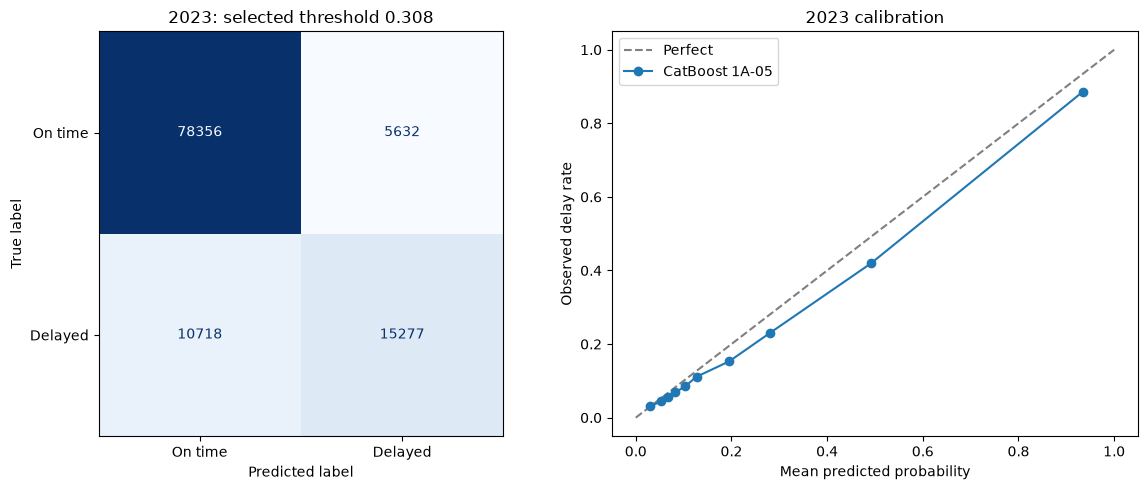

In [12]:
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title(f"2023: selected threshold {selected_threshold:.3f}")
predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[1].plot(predicted, observed, marker="o", label="CatBoost 1A-05")
axes[1].set(
    title="2023 calibration",
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
)
axes[1].legend()
fig.tight_layout()
plt.show()


## Inspect feature importance and publishable values

Importance describes predictive use within this fitted model, not causal effects. The final-tail assignment limitation remains unchanged.


In [13]:
importance_table = (
    pd.DataFrame({
        "feature": feature_variants[selected_variant],
        "importance": final_model.get_feature_importance(),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_table.head(25))

default = evaluation_results.loc["CatBoost 1A-05 (default)"]
selected = evaluation_results.loc["CatBoost 1A-05 (training-selected)"]
selected_training = chronology_results.set_index("has_time").loc[selected_has_time]
publishable_summary = pd.Series({
    "selected representation": selected_variant,
    "source fields": len(feature_variants[selected_variant]),
    "categorical fields": len(categorical_features),
    "numeric fields": len(feature_variants[selected_variant]) - len(categorical_features),
    "representation guardrail passed": screen_passes,
    "parameter guardrail passed": parameter_passes,
    "chronology guardrail passed": chronology_passes,
    "selected depth": selected_parameters["depth"],
    "selected learning rate": selected_parameters["learning_rate"],
    "selected random strength": selected_parameters["random_strength"],
    "selected L2 leaf regularization": CONTROL_L2_LEAF_REG,
    "selected trees": selected_iterations,
    "selected has_time": selected_has_time,
    "training CV AP": selected_training["mean_average_precision"],
    "training CV ROC AUC": selected_training["mean_roc_auc"],
    "training CV Brier": selected_training["mean_brier_score"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "representation screen seconds": screen_seconds,
    "parameter search seconds": search_seconds,
    "chronology comparison seconds": chronology_seconds,
    "final fit seconds": final_fit_seconds,
}, name="CatBoost 1A Experiment 05 Appendix F values")
publishable_summary.to_frame()


,feature,importance
0,ROTATION_LOG_ACTUAL_TURN_MINUTES,14.5639
1,ROTATION_ACTUAL_TURN_MINUTES,13.6299
2,ROTATION_INBOUND_ARR_DELAY,6.7206
3,ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,5.5597
4,ROTATION_STATUS,5.4126
5,ROTATION_SCHEDULED_TURN_MINUTES,5.2039
6,ROTATION_LOG_SCHEDULED_TURN_MINUTES,4.5631
7,CRSDepTime,3.4905
8,Reporting_Airline,3.4422
9,Distance,3.2985


,CatBoost 1A Experiment 05 Appendix F values
selected representation,control_41
source fields,41
categorical fields,6
numeric fields,35
representation guardrail passed,False
parameter guardrail passed,False
chronology guardrail passed,False
selected depth,6
selected learning rate,0.0300
selected random strength,1.0000


## Interpretation checklist

1. Did an expanded representation clear the predeclared 2019 guardrail?
2. Did added capacity or chronological handling clear the same guardrail?
3. Does the frozen 2023 result improve CatBoost 1A-04 by enough to replace it?
4. Retain CatBoost 1A-04 unless the gain is material and probability quality and thresholded performance remain acceptable.
5. Keep the final-tail assignment limitation explicit and keep 2024 untouched.
